In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import math
import pickle

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# from fix_data_leakage import scale_data_without_leakage, create_sequences
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [8]:
# df = pd.read_csv("E:\Document\PROJECT\data\processed\data2225_done.csv")
# df = pd.read_csv("data/processed/data2225_done.csv")


df = pd.read_csv('/content/data2225_done.csv')
df = df.drop(columns=['Unnamed: 0', 'Local Time.1'])
df.head()

,Local Time,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,IsHoliday,Accumulated Hours of Rain
0,2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100,0.00,1020,95.0,15.5,0.6,2.00,False,0
1,2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91,0.00,1021,94.0,15.4,0.7,2.33,False,0
2,2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83,0.50,1022,93.0,15.3,1.0,2.66,False,1
3,2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75,0.75,1022,93.0,15.2,1.5,3.00,False,2
4,2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83,0.00,1021,87.0,15.6,1.9,3.00,False,0


In [9]:

df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.set_index('Local Time').sort_index()

In [10]:
# ===== Time features =====
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek   # Monday=0, Sunday=6
df["month"] = df.index.month

# ===== PM25 lag features =====
df["PM25_lag_1"] = df["PM25"].shift(1)
df["PM25_lag_3"] = df["PM25"].shift(3)
df["PM25_lag_24"] = df["PM25"].shift(24)

# ===== Rolling mean của PM25 quá khứ =====
# shift(1) để không ăn vào giá trị hiện tại
df["PM25_roll_mean_3"] = df["PM25"].shift(1).rolling(window=3).mean()
df["PM25_roll_mean_6"] = df["PM25"].shift(1).rolling(window=6).mean()
df["PM25_roll_mean_24"] = df["PM25"].shift(1).rolling(window=24).mean()

# nếu muốn thêm rolling std
df["PM25_roll_std_24"] = df["PM25"].shift(1).rolling(window=24).std()

# bỏ các dòng đầu bị NaN do lag/rolling
df = df.dropna().copy()

print(df[[
    "PM25", "PM25_lag_1", "PM25_lag_3", "PM25_lag_24",
    "PM25_roll_mean_3", "PM25_roll_mean_6", "PM25_roll_mean_24",
    "hour", "dayofweek", "month"
]].head())

                      PM25  PM25_lag_1  PM25_lag_3  PM25_lag_24  \
Local Time                                                        
2022-01-14 07:00:00  24.75       27.31       32.42        17.08   
2022-01-14 08:00:00  22.36       24.75       29.87        16.75   
2022-01-14 09:00:00  19.97       22.36       27.31        16.42   
2022-01-14 10:00:00  17.57       19.97       24.75        16.09   
2022-01-14 11:00:00  16.01       17.57       22.36        16.17   

                     PM25_roll_mean_3  PM25_roll_mean_6  PM25_roll_mean_24  \
Local Time                                                                   
2022-01-14 07:00:00         29.866667         31.063333          22.317500   
2022-01-14 08:00:00         27.310000         29.825000          22.637083   
2022-01-14 09:00:00         24.806667         28.175000          22.870833   
2022-01-14 10:00:00         22.360000         26.113333          23.018750   
2022-01-14 11:00:00         19.966667         23.638333       

In [11]:
num_cols = df.select_dtypes(include=[np.number]).columns

skew_df = pd.DataFrame({
    "skew": df[num_cols].skew(numeric_only=True),
    "mean": df[num_cols].mean(numeric_only=True),
    "median": df[num_cols].median(numeric_only=True),
    "min": df[num_cols].min(numeric_only=True),
    "max": df[num_cols].max(numeric_only=True)
}).sort_values("skew", ascending=False)

print(skew_df)

                               skew         mean       median         min  \
Precipitation              6.435974     0.308527     0.000000    0.000000   
Accumulated Hours of Rain  5.659202     1.286397     0.000000    0.000000   
NO2                        4.910769    18.335192    11.000000    0.000000   
PM10                       4.818031    42.725697    30.330000    0.480000   
CO                         4.341903   523.411147   195.500000    0.000000   
SO2                        4.250056    36.284525    29.820000    0.000000   
PM25_lag_24                2.693140    21.112296    16.500000    0.480000   
PM25_lag_3                 2.687197    21.134762    16.500000    0.480000   
PM25_lag_1                 2.686935    21.135364    16.500000    0.480000   
PM25                       2.686771    21.135764    16.500000    0.480000   
PM25_roll_std_24           2.637767     7.661738     5.576020    0.292356   
PM25_roll_mean_3           2.528159    21.135076    16.750000    0.480000   

In [12]:
skew_df["abs_skew"] = skew_df["skew"].abs()

strong_skew = skew_df[skew_df["abs_skew"] >= 1].sort_values("abs_skew", ascending=False)
moderate_skew = skew_df[(skew_df["abs_skew"] >= 0.5) & (skew_df["abs_skew"] < 1)]

print("=== Cột lệch mạnh ===")
print(strong_skew[["skew", "mean", "median", "min", "max"]])

print("\n=== Cột lệch vừa ===")
print(moderate_skew[["skew", "mean", "median", "min", "max"]])

=== Cột lệch mạnh ===
                               skew        mean      median       min  \
Precipitation              6.435974    0.308527    0.000000  0.000000   
Accumulated Hours of Rain  5.659202    1.286397    0.000000  0.000000   
NO2                        4.910769   18.335192   11.000000  0.000000   
PM10                       4.818031   42.725697   30.330000  0.480000   
CO                         4.341903  523.411147  195.500000  0.000000   
SO2                        4.250056   36.284525   29.820000  0.000000   
PM25_lag_24                2.693140   21.112296   16.500000  0.480000   
PM25_lag_3                 2.687197   21.134762   16.500000  0.480000   
PM25_lag_1                 2.686935   21.135364   16.500000  0.480000   
PM25                       2.686771   21.135764   16.500000  0.480000   
PM25_roll_std_24           2.637767    7.661738    5.576020  0.292356   
PM25_roll_mean_3           2.528159   21.135076   16.750000  0.480000   
PM25_roll_mean_6           2.

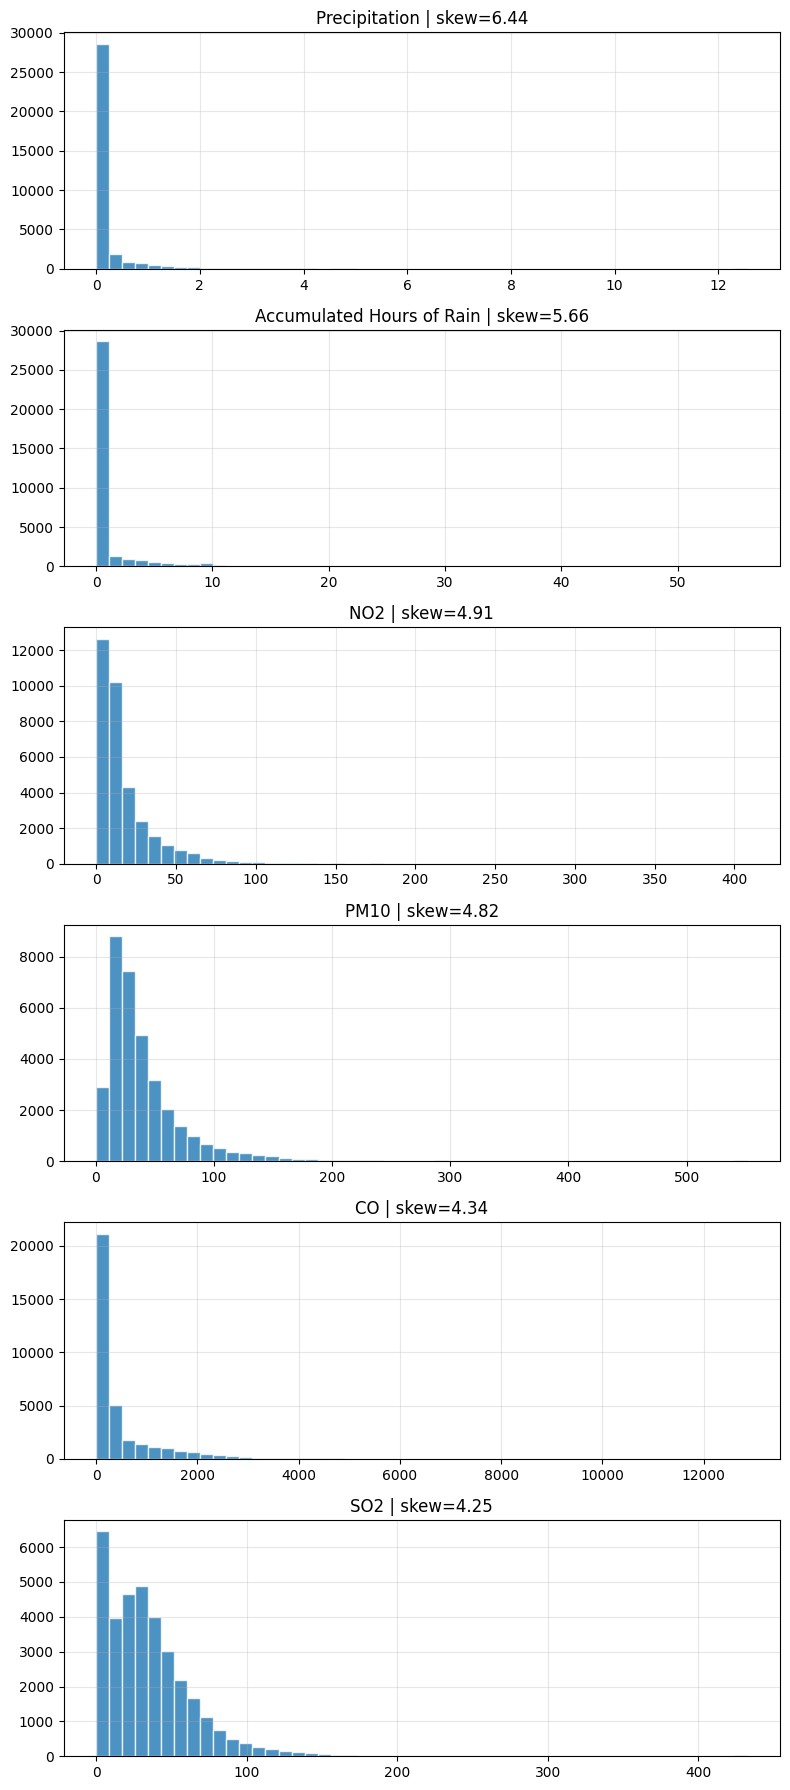

In [13]:
cols_to_plot = strong_skew.index.tolist()[:6]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(8, 3*len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df[col].dropna(), bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"{col} | skew={df[col].skew():.2f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
(df["PM25"] < 0).sum(), df.loc[df["PM25"] < 0, "PM25"].describe()

(np.int64(0),
 count    0.0
 mean     NaN
 std      NaN
 min      NaN
 25%      NaN
 50%      NaN
 75%      NaN
 max      NaN
 Name: PM25, dtype: float64)

In [15]:
# đảm bảo index là datetime
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# ===== Split theo thời gian =====
train_end = "2023-12-31"
val_start = "2024-01-01"
val_end = "2024-12-31"
test_start = "2025-01-01"

train_df = df[:train_end].copy()
val_df   = df[val_start:val_end].copy()
test_df  = df[test_start:].copy()

print("Kich thuoc train/val/test:", train_df.shape, val_df.shape, test_df.shape)

Kich thuoc train/val/test: (17201, 25) (8784, 25) (8750, 25)


In [16]:
y_train_raw = train_df["PM25"].to_numpy()
y_val_raw = val_df["PM25"].to_numpy()
y_test_raw = test_df["PM25"].to_numpy()

train_log = np.log1p(train_df["PM25"])
val_log = np.log1p(val_df["PM25"])
test_log = np.log1p(test_df["PM25"])

y_train_t = train_log.to_numpy()
y_val_t = val_log.to_numpy()
y_test_t = test_log.to_numpy()

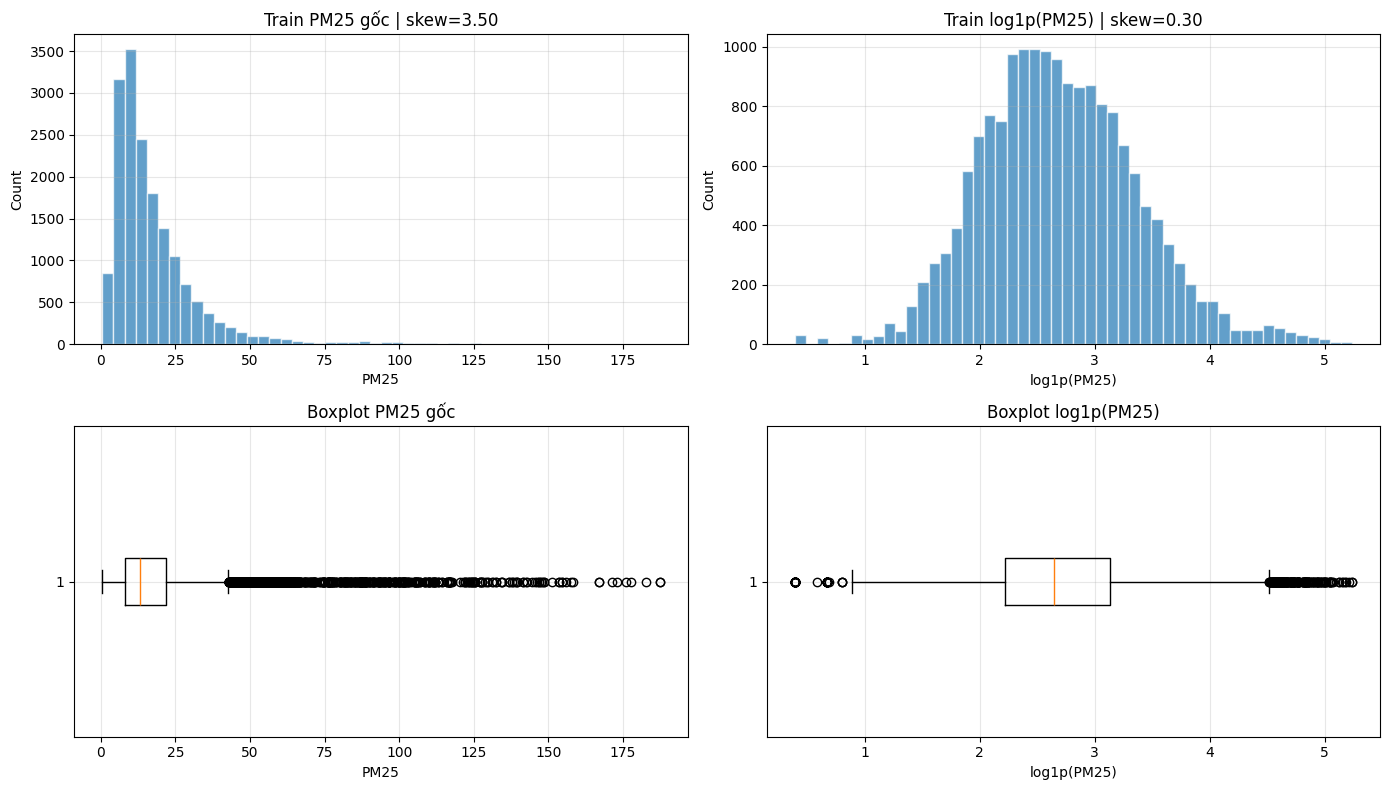

Do lech (skew) du lieu goc: 3.499951797994981
Do lech (skew) sau log: 0.3033528055592822


In [17]:

y_train_raw_1d = y_train_raw.ravel()
y_val_raw_1d   = y_val_raw.ravel()
y_test_raw_1d  = y_test_raw.ravel()

y_train_t_1d = y_train_t.ravel()
y_val_t_1d   = y_val_t.ravel()
y_test_t_1d  = y_test_t.ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Histogram trước log
axes[0, 0].hist(y_train_raw_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 0].set_title(f"Train PM25 gốc | skew={pd.Series(y_train_raw_1d).skew():.2f}")
axes[0, 0].set_xlabel("PM25")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3)

# 2) Histogram sau log1p
axes[0, 1].hist(y_train_t_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 1].set_title(f"Train log1p(PM25) | skew={pd.Series(y_train_t_1d).skew():.2f}")
axes[0, 1].set_xlabel("log1p(PM25)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

# 3) Boxplot trước log
axes[1, 0].boxplot(y_train_raw_1d, vert=False)
axes[1, 0].set_title("Boxplot PM25 gốc")
axes[1, 0].set_xlabel("PM25")
axes[1, 0].grid(alpha=0.3)

# 4) Boxplot sau log1p
axes[1, 1].boxplot(y_train_t_1d, vert=False)
axes[1, 1].set_title("Boxplot log1p(PM25)")
axes[1, 1].set_xlabel("log1p(PM25)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Do lech (skew) du lieu goc:", pd.Series(y_train_raw_1d).skew())
print("Do lech (skew) sau log:", pd.Series(y_train_t_1d).skew())

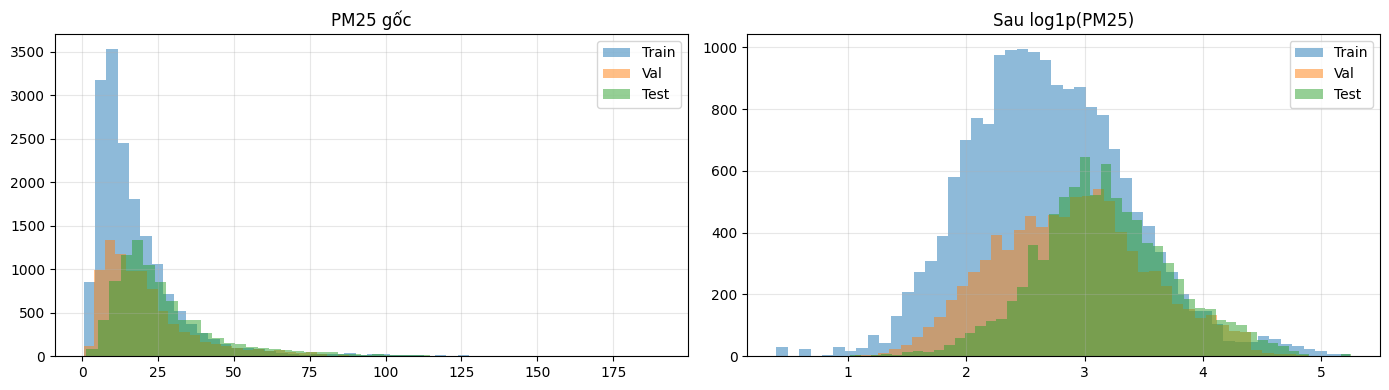

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train_raw.ravel(), bins=50, alpha=0.5, label="Train")
axes[0].hist(y_val_raw.ravel(), bins=50, alpha=0.5, label="Val")
axes[0].hist(y_test_raw.ravel(), bins=50, alpha=0.5, label="Test")
axes[0].set_title("PM25 gốc")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(y_train_t.ravel(), bins=50, alpha=0.5, label="Train")
axes[1].hist(y_val_t.ravel(), bins=50, alpha=0.5, label="Val")
axes[1].hist(y_test_t.ravel(), bins=50, alpha=0.5, label="Test")
axes[1].set_title("Sau log1p(PM25)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

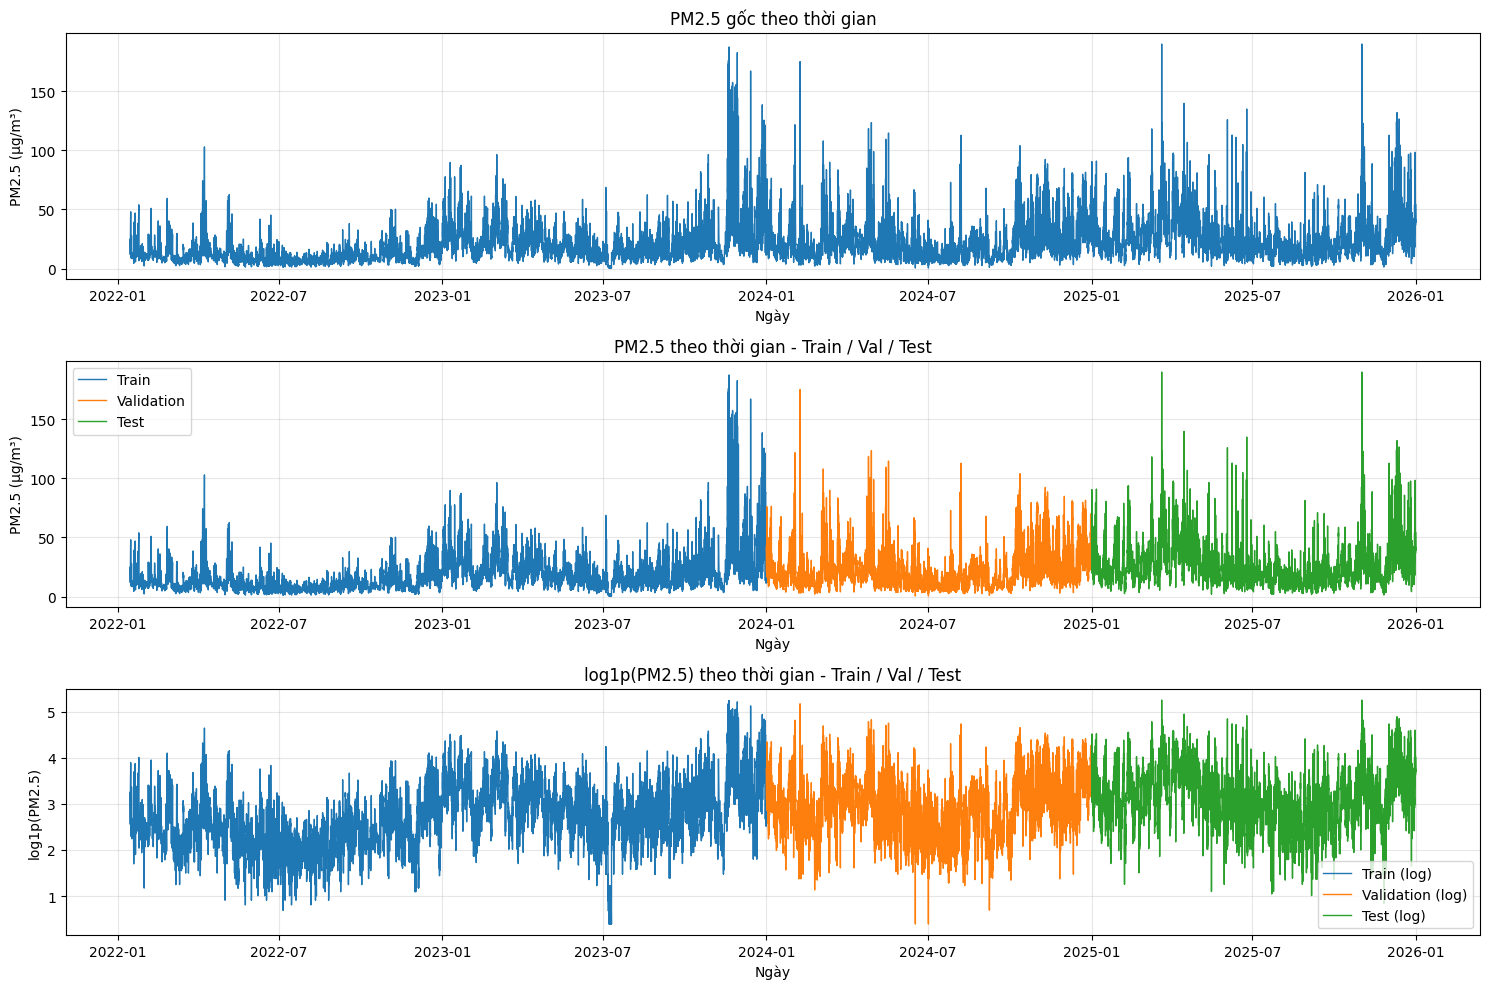

In [19]:


# ===== Tạo log PM25 =====
train_log = np.log1p(train_df["PM25"])
val_log   = np.log1p(val_df["PM25"])
test_log  = np.log1p(test_df["PM25"])

# ===== Vẽ =====
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1) PM2.5 gốc toàn bộ theo thời gian
axes[0].plot(df.index, df["PM25"], linewidth=1)
axes[0].set_title("PM2.5 gốc theo thời gian")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xlabel("Ngày")
axes[0].grid(True, alpha=0.3)

# 2) PM2.5 gốc theo split Train / Val / Test
axes[1].plot(train_df.index, train_df["PM25"], label="Train", linewidth=1)
axes[1].plot(val_df.index, val_df["PM25"], label="Validation", linewidth=1)
axes[1].plot(test_df.index, test_df["PM25"], label="Test", linewidth=1)
axes[1].set_title("PM2.5 theo thời gian - Train / Val / Test")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("Ngày")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) log1p(PM2.5) theo split Train / Val / Test
axes[2].plot(train_df.index, train_log, label="Train (log)", linewidth=1)
axes[2].plot(val_df.index, val_log, label="Validation (log)", linewidth=1)
axes[2].plot(test_df.index, test_log, label="Test (log)", linewidth=1)
axes[2].set_title("log1p(PM2.5) theo thời gian - Train / Val / Test")
axes[2].set_ylabel("log1p(PM2.5)")
axes[2].set_xlabel("Ngày")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:

spearman_pm25 = train_df.corr(method="spearman")["PM25"].drop("PM25")
print(spearman_pm25)

CO                           0.469454
NO2                          0.115273
O3                          -0.084273
PM10                         0.439311
SO2                          0.143897
Clouds                       0.030035
Precipitation               -0.123841
Pressure                     0.324898
Relative Humidity           -0.043871
Temperature                 -0.283757
UV Index                    -0.090384
Wind Speed                  -0.298457
IsHoliday                    0.062443
Accumulated Hours of Rain   -0.121939
hour                         0.023752
dayofweek                   -0.005958
month                       -0.059311
PM25_lag_1                   0.935196
PM25_lag_3                   0.834184
PM25_lag_24                  0.695402
PM25_roll_mean_3             0.906484
PM25_roll_mean_6             0.863811
PM25_roll_mean_24            0.801621
PM25_roll_std_24             0.659200
Name: PM25, dtype: float64


In [21]:

df = df.copy()

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

for lag in [1, 3, 24, 72, 168]:
    df[f"PM25_lag_{lag}"] = df["PM25"].shift(lag)

shifted = df["PM25"].shift(1)
for window in [24, 72, 168]:
    df[f"PM25_roll_mean_{window}"] = shifted.rolling(window=window).mean()
    df[f"PM25_roll_std_{window}"] = shifted.rolling(window=window).std()
    df[f"PM25_roll_max_{window}"] = shifted.rolling(window=window).max()
    df[f"PM25_roll_min_{window}"] = shifted.rolling(window=window).min()

df["PM25_ewm_mean_24"] = shifted.ewm(span=24, adjust=False).mean()
df["PM25_ewm_mean_72"] = shifted.ewm(span=72, adjust=False).mean()
df["PM25_diff_1"] = shifted.diff(1)
df["PM25_diff_24"] = shifted.diff(24)

df = df.dropna().copy()

base_features = [
    "PM25_lag_1", "PM25_lag_3", "PM25_lag_24", "PM25_lag_72", "PM25_lag_168",
    "PM25_roll_mean_24", "PM25_roll_mean_72", "PM25_roll_mean_168",
    "PM25_roll_std_24", "PM25_roll_std_72", "PM25_roll_std_168",
    "PM25_roll_max_24", "PM25_roll_max_72", "PM25_roll_max_168",
    "PM25_roll_min_24", "PM25_roll_min_72", "PM25_roll_min_168",
    "PM25_ewm_mean_24", "PM25_ewm_mean_72",
    "PM25_diff_1", "PM25_diff_24",
]

weather_features = [
    "Temperature", "Pressure", "Wind Speed",
    "Clouds", "Precipitation", "Relative Humidity",
    "Accumulated Hours of Rain",
]

pollution_features = ["PM10", "CO", "NO2", "O3", "SO2"]

calendar_features = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "IsHoliday",
]

feature_groups = {
    "base": base_features,
    "weather": weather_features,
    "pollution": pollution_features,
    "calendar": calendar_features,
}

candidate_feature_sets = {
    "base": base_features,
    "base_weather": base_features + weather_features,
    "base_weather_pollution": base_features + weather_features + pollution_features,
    "manual_v1": base_features
        + ["PM10", "CO", "NO2"]
        + ["Temperature", "Pressure", "Wind Speed", "Relative Humidity", "Precipitation", "Clouds"]
        + ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos", "IsHoliday"],
    "all": base_features + weather_features + pollution_features + calendar_features,
}

GRA_POOL_NAME = "all"
GRA_TOP_K = 12
GRA_RHO = 0.5


def _minmax_01(values):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmax, vmin):
        return np.zeros_like(values, dtype=np.float64)
    return (values - vmin) / (vmax - vmin)


def compute_gra_scores(X_df, y_series, rho=0.5):
    ref = _minmax_01(np.asarray(y_series, dtype=np.float64).reshape(-1))
    diffs = []
    normalized = {}

    for col in X_df.columns:
        seq = _minmax_01(X_df[col].to_numpy(dtype=np.float64))
        normalized[col] = seq
        diffs.append(np.abs(ref - seq))

    diff_matrix = np.vstack(diffs)
    delta_min = float(np.min(diff_matrix))
    delta_max = float(np.max(diff_matrix))
    if np.isclose(delta_max, 0.0):
        delta_max = 1.0

    rows = []
    for col in X_df.columns:
        diff = np.abs(ref - normalized[col])
        coeff = (delta_min + rho * delta_max) / (diff + rho * delta_max)
        rows.append({
            "feature": col,
            "gra_score": float(np.mean(coeff)),
        })

    return pd.DataFrame(rows).sort_values(["gra_score", "feature"], ascending=[False, True]).reset_index(drop=True)


for name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        print(f"{name}: thieu cot -> {missing_cols}")
    else:
        print(f"{name}: {len(cols)} dac trung")

feature_cols = candidate_feature_sets["manual_v1"]
print("Bo dac trung goi y de thu dau tien:", feature_cols)


base: 21 dac trung
base_weather: 28 dac trung
base_weather_pollution: 33 dac trung
manual_v1: 37 dac trung
all: 40 dac trung
Bo dac trung goi y de thu dau tien: ['PM25_lag_1', 'PM25_lag_3', 'PM25_lag_24', 'PM25_lag_72', 'PM25_lag_168', 'PM25_roll_mean_24', 'PM25_roll_mean_72', 'PM25_roll_mean_168', 'PM25_roll_std_24', 'PM25_roll_std_72', 'PM25_roll_std_168', 'PM25_roll_max_24', 'PM25_roll_max_72', 'PM25_roll_max_168', 'PM25_roll_min_24', 'PM25_roll_min_72', 'PM25_roll_min_168', 'PM25_ewm_mean_24', 'PM25_ewm_mean_72', 'PM25_diff_1', 'PM25_diff_24', 'PM10', 'CO', 'NO2', 'Temperature', 'Pressure', 'Wind Speed', 'Relative Humidity', 'Precipitation', 'Clouds', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']


In [22]:
train_df = df[:train_end].copy()
val_df   = df[val_start:val_end].copy()
test_df  = df[test_start:].copy()

gra_pool_cols = candidate_feature_sets[GRA_POOL_NAME]
gra_scores_df = compute_gra_scores(train_df[gra_pool_cols], train_df["PM25"], rho=GRA_RHO)
gra_topk_features = gra_scores_df["feature"].head(GRA_TOP_K).tolist()
candidate_feature_sets["gra_topk"] = gra_topk_features

print("=== Các đặc trưng GRA xếp hạng cao nhất trên tập huấn luyện ===")
display(gra_scores_df.head(20))
print(f"Tập ứng viên GRA: {GRA_POOL_NAME}, top_k = {GRA_TOP_K}")
print("Các đặc trưng GRA được chọn:", gra_topk_features)

candidate_data = {}

for name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        print(f"{name}: thiếu cột -> {missing_cols}")
        continue

    candidate_data[name] = {
        "feature_cols": cols,
        "train_X": train_df[cols].copy(),
        "val_X": val_df[cols].copy(),
        "test_X": test_df[cols].copy(),
        "train_y": train_df[["PM25"]].copy(),
        "val_y": val_df[["PM25"]].copy(),
        "test_y": test_df[["PM25"]].copy(),
    }

for name, data in candidate_data.items():
    print(
        "Kích thước dữ liệu của bộ",
        name,
        ":",
        data["train_X"].shape,
        data["val_X"].shape,
        data["test_X"].shape,
    )

ablation_order = list(candidate_data.keys())
print("Thứ tự thử nghiệm ablation:", ablation_order)

=== Các đặc trưng GRA xếp hạng cao nhất trên tập huấn luyện ===


,feature,gra_score
0,PM25_lag_1,0.970279
1,PM25_lag_3,0.950075
2,PM25_lag_24,0.931770
3,PM25_roll_std_24,0.923453
4,PM25_lag_72,0.914090
5,PM25_lag_168,0.907172
6,PM25_ewm_mean_24,0.906711
7,PM25_roll_std_72,0.902547
8,PM10,0.895952
9,PM25_roll_mean_24,0.891645


Tập ứng viên GRA: all, top_k = 12
Các đặc trưng GRA được chọn: ['PM25_lag_1', 'PM25_lag_3', 'PM25_lag_24', 'PM25_roll_std_24', 'PM25_lag_72', 'PM25_lag_168', 'PM25_ewm_mean_24', 'PM25_roll_std_72', 'PM10', 'PM25_roll_mean_24', 'PM25_roll_max_24', 'PM25_roll_min_24']
Kích thước dữ liệu của bộ base : (17033, 21) (8784, 21) (8750, 21)
Kích thước dữ liệu của bộ base_weather : (17033, 28) (8784, 28) (8750, 28)
Kích thước dữ liệu của bộ base_weather_pollution : (17033, 33) (8784, 33) (8750, 33)
Kích thước dữ liệu của bộ manual_v1 : (17033, 37) (8784, 37) (8750, 37)
Kích thước dữ liệu của bộ all : (17033, 40) (8784, 40) (8750, 40)
Kích thước dữ liệu của bộ gra_topk : (17033, 12) (8784, 12) (8750, 12)
Thứ tự thử nghiệm ablation: ['base', 'base_weather', 'base_weather_pollution', 'manual_v1', 'all', 'gra_topk']


In [23]:
# ===== Cấu hình GRU + Walk-forward =====
LOOKBACK = 336
HORIZON = 24
EVAL_SIZE = 336
STEP_SIZE = 24
MAX_FOLDS = 3
EPOCHS = 80
BATCH_SIZE = 32
SEED = 42
TARGET_TRANSFORM_MODE = "sqrt"
SELECTED_FEATURE_SET = "manual_v1"
INNER_VAL_SIZE = 336
PEAK_QUANTILE = 0.90
PEAK_WEIGHT = 6.0
HUBER_DELTA = 1.0
FEATURE_SET_COMPARE = ["gra_topk", "base_weather_pollution", "manual_v1"]

np.random.seed(SEED)
tf.random.set_seed(SEED)

feature_cols = candidate_feature_sets[SELECTED_FEATURE_SET]
print("Bộ đặc trưng đang dùng:", SELECTED_FEATURE_SET)
print("Số lượng đặc trưng:", len(feature_cols))
print("Danh sách cột đặc trưng:", feature_cols)
print("Số bước nhìn lại / số bước dự báo (LOOKBACK/HORIZON):", LOOKBACK, HORIZON)
print("Kiểu biến đổi biến mục tiêu:", TARGET_TRANSFORM_MODE)
print("Thiết lập đánh giá cuốn chiếu theo thời gian: eval_size =", EVAL_SIZE, "step_size =", STEP_SIZE, "max_folds =", MAX_FOLDS)
print("Kích thước tập validation nội bộ:", INNER_VAL_SIZE)
print("Hàm mất mát có trọng số cho đỉnh: quantile =", PEAK_QUANTILE, "peak_weight =", PEAK_WEIGHT, "delta =", HUBER_DELTA)
print("Cấu hình huấn luyện: EPOCHS =", EPOCHS, "BATCH_SIZE =", BATCH_SIZE)

Bộ đặc trưng đang dùng: manual_v1
Số lượng đặc trưng: 37
Danh sách cột đặc trưng: ['PM25_lag_1', 'PM25_lag_3', 'PM25_lag_24', 'PM25_lag_72', 'PM25_lag_168', 'PM25_roll_mean_24', 'PM25_roll_mean_72', 'PM25_roll_mean_168', 'PM25_roll_std_24', 'PM25_roll_std_72', 'PM25_roll_std_168', 'PM25_roll_max_24', 'PM25_roll_max_72', 'PM25_roll_max_168', 'PM25_roll_min_24', 'PM25_roll_min_72', 'PM25_roll_min_168', 'PM25_ewm_mean_24', 'PM25_ewm_mean_72', 'PM25_diff_1', 'PM25_diff_24', 'PM10', 'CO', 'NO2', 'Temperature', 'Pressure', 'Wind Speed', 'Relative Humidity', 'Precipitation', 'Clouds', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']
Số bước nhìn lại / số bước dự báo (LOOKBACK/HORIZON): 336 24
Kiểu biến đổi biến mục tiêu: sqrt
Thiết lập đánh giá cuốn chiếu theo thời gian: eval_size = 336 step_size = 24 max_folds = 3
Kích thước tập validation nội bộ: 336
Hàm mất mát có trọng số cho đỉnh: quantile = 0.9 peak_weight = 4.0 delta = 1.0
Cấu hình huấn luyện: EPOCHS

In [24]:
# ===== Sequence building + Seq2Seq GRU / Attention model =====

# T?o c?a s? tr??t cho b?i to?n multi-step forecasting.
def make_sequences(X, y, lookback=72, horizon=72):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    X_seq, y_seq = [], []
    max_start = len(X) - lookback - horizon + 1
    if max_start <= 0:
        return np.empty((0, lookback, X.shape[1]), dtype=np.float32), np.empty((0, horizon), dtype=np.float32)

    for i in range(max_start):
        X_seq.append(X[i:i + lookback])
        y_seq.append(y[i + lookback:i + lookback + horizon])

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)


# Xây dựng mô hình Seq2Seq GRU với tùy chọn attention và các tham số cấu hình linh hoạt.
def build_gru_model(
    lookback,
    n_features,
    horizon,
    gru_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=5e-4,
    loss_fn='mse',
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(gru_units, int):
        gru_units = (gru_units, max(gru_units // 2, 32))
    elif len(gru_units) == 1:
        gru_units = (gru_units[0], max(gru_units[0] // 2, 32))

    encoder_units = gru_units[0]
    decoder_units = tuple(gru_units[1:]) if len(gru_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_last_units = decoder_units[-1]
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    inputs = tf.keras.layers.Input(shape=(lookback, n_features))

    # Encoder tr? v? to?n b? hidden states ?? attention nh?n l?i to?n chu?i input.
    encoder_outputs, encoder_state = tf.keras.layers.GRU(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="encoder_gru",
    )(inputs)

    # Decoder b?t ??u t? tr?ng th?i cu?i c?a encoder v? m? r?ng ra horizon b??c.
    x = tf.keras.layers.RepeatVector(horizon, name="repeat_context")(encoder_state)

    for i, units in enumerate(decoder_units, start=1):
        x = tf.keras.layers.GRU(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"decoder_gru_{i}",
        )(x)

    decoder_outputs = x

    if use_attention:
        # Chi?u encoder states v? c?ng k?ch th??c v?i decoder tr??c khi t?nh attention.
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(
                decoder_last_units,
                kernel_regularizer=regularizer,
                name="encoder_attention_projection",
            )(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="temporal_attention")([
            decoder_outputs,
            attention_values,
        ])
        x = tf.keras.layers.Concatenate(name="decoder_attention_concat")([
            decoder_outputs,
            attention_context,
        ])
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1), name="time_distributed_output")(x)
    outputs = tf.keras.layers.Reshape((horizon,), name="forecast_output")(x)
    model_name = "seq2seq_gru_attention" if use_attention else "seq2seq_gru"
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


# Tạo hàm mất mát Huber có trọng số cho các điểm đỉnh (peak) dựa trên ngưỡng và trọng số đã định.
def make_weighted_huber_loss(peak_threshold, peak_weight=6.0, delta=1.0, horizon=72):
    peak_threshold = tf.constant(float(peak_threshold), dtype=tf.float32)
    peak_weight = tf.constant(float(peak_weight), dtype=tf.float32)
    delta = tf.constant(float(delta), dtype=tf.float32)
    step_weights = tf.reshape(tf.linspace(1.0, 1.8, horizon), (1, horizon))

    def loss(y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)
        huber = tf.where(
            abs_error <= delta,
            0.5 * tf.square(error),
            delta * (abs_error - 0.5 * delta),
        )
        peak_weights = 1.0 + peak_weight * tf.cast(y_true >= peak_threshold, tf.float32)
        return tf.reduce_mean(huber * peak_weights * step_weights)

    return loss


In [25]:
# ===== Metrics + aggregation =====

# T?nh c?c metric c? b?n tr?n vector d? b?o ph?ng.
def compute_regression_metrics(y_true_flat, y_pred_flat, peak_quantile=0.90):
    y_true_flat = np.asarray(y_true_flat, dtype=np.float64).reshape(-1)
    y_pred_flat = np.asarray(y_pred_flat, dtype=np.float64).reshape(-1)

    metrics = {
        "mae": mean_absolute_error(y_true_flat, y_pred_flat),
        "rmse": np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)),
        "mape": np.mean(
            np.abs((y_true_flat - y_pred_flat) / np.clip(np.abs(y_true_flat), 1e-6, None))
        ) * 100,
    }

    peak_threshold = float(np.quantile(y_true_flat, peak_quantile))
    peak_mask = y_true_flat >= peak_threshold
    metrics["peak_threshold"] = peak_threshold
    metrics["peak_mae"] = mean_absolute_error(y_true_flat[peak_mask], y_pred_flat[peak_mask]) if np.any(peak_mask) else np.nan
    return metrics


def aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d):
    rows = []
    y_true_2d = np.asarray(y_true_2d, dtype=np.float64)
    y_pred_2d = np.asarray(y_pred_2d, dtype=np.float64)

    for seq_idx in range(y_pred_2d.shape[0]):
        for h in range(y_pred_2d.shape[1]):
            rows.append({
                "timestamp": eval_index[seq_idx + h],
                "horizon_step": h + 1,
                "y_true": y_true_2d[seq_idx, h],
                "y_pred": y_pred_2d[seq_idx, h],
            })

    long_df = pd.DataFrame(rows)
    agg_df = (
        long_df.groupby("timestamp", as_index=False)
        .agg(
            y_true=("y_true", "mean"),
            y_pred=("y_pred", "mean"),
            pred_std=("y_pred", "std"),
            n_votes=("y_pred", "size"),
        )
        .sort_values("timestamp")
    )
    agg_df["pred_std"] = agg_df["pred_std"].fillna(0.0)
    return long_df, agg_df


# Tính metric riêng cho từng horizon step.
def compute_horizon_step_metrics(long_df, peak_quantile=0.90):
    rows = []
    for horizon_step, step_df in long_df.groupby("horizon_step", sort=True):
        metrics = compute_regression_metrics(
            step_df["y_true"].to_numpy(),
            step_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        rows.append({
            "horizon_step": int(horizon_step),
            "n_points": int(len(step_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })
    return pd.DataFrame(rows)


# Gom toàn bộ quy trình đánh giá multi-step forecasting: từ long format, aggregate theo timestamp, tính metric theo horizon step, và metric tổng thể.
def summarize_multistep_predictions(eval_index, y_true_2d, y_pred_2d, peak_quantile=0.90):
    long_df, agg_df = aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d)
    horizon_metrics_df = compute_horizon_step_metrics(long_df, peak_quantile=peak_quantile)
    step1_df = long_df[long_df["horizon_step"] == 1].sort_values("timestamp").reset_index(drop=True)

    raw_metrics = compute_regression_metrics(
        np.asarray(y_true_2d, dtype=np.float64).reshape(-1),
        np.asarray(y_pred_2d, dtype=np.float64).reshape(-1),
        peak_quantile=peak_quantile,
    )
    step1_metrics = compute_regression_metrics(
        step1_df["y_true"].to_numpy(),
        step1_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    agg_metrics = compute_regression_metrics(
        agg_df["y_true"].to_numpy(),
        agg_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )

    return {
        "long_df": long_df,
        "agg_df": agg_df,
        "step1_df": step1_df,
        "horizon_metrics_df": horizon_metrics_df,
        "raw_metrics": raw_metrics,
        "step1_metrics": step1_metrics,
        "agg_metrics": agg_metrics,
    }


In [26]:
# ===== Target transform =====

# BBiến đổi mục tiêu PM25 để giảm độ lệch và đảm bảo không có giá trị âm, hỗ trợ các kiểu biến đổi khác nhau (log1p, sqrt, raw) và chuẩn hóa bằng StandardScaler.
def transform_target(y_raw, scaler=None, fit=False, mode="log1p"):
    y_raw = np.asarray(y_raw, dtype=np.float64).reshape(-1)
    y_clip = np.clip(y_raw, 0.0, None)

    if mode == "log1p":
        y_t = np.log1p(y_clip).reshape(-1, 1)
    elif mode == "sqrt":
        y_t = np.sqrt(y_clip).reshape(-1, 1)
    elif mode == "raw":
        y_t = y_raw.reshape(-1, 1)
    else:
        raise ValueError(f"Ch? ?? chuy?n ??i m?c ti?u kh?ng ???c h? tr?: {mode}")

    if fit:
        scaler = StandardScaler()
        scaler.fit(y_t)
    elif scaler is None:
        raise ValueError("Khi fit=False, scaler không ???c cung c?p")

    y_scaled = scaler.transform(y_t).reshape(-1)
    return y_scaled, scaler


# tạo hàm nghịch đảo để chuyển dự đoán đã được biến đổi trở lại dạng gốc, đảm bảo không có giá trị âm.
def inverse_target(y_scaled, scaler, mode="log1p"):
    y_scaled = np.asarray(y_scaled, dtype=np.float64)
    original_shape = y_scaled.shape
    y_unscaled = scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(original_shape)

    if mode == "log1p":
        y_raw = np.expm1(y_unscaled)
    elif mode == "sqrt":
        y_raw = np.square(np.clip(y_unscaled, 0.0, None))
    elif mode == "raw":
        y_raw = y_unscaled
    else:
        raise ValueError(f"Ch? ?? chuy?n ??i m?c ti?u kh?ng ???c h? tr?: {mode}")

    return np.clip(y_raw, 0.0, None)


In [27]:
# ===== Data prep for train/eval =====

# Scale feature/target và tạo sequence cho huấn luyện và đánh giá cuốn chiếu theo thời gian.
def prepare_train_eval_sequences(train_X_df, train_y_df, eval_X_df, eval_y_df, lookback=72, horizon=72, target_mode="log1p"):
    if len(train_X_df) <= lookback:
        raise ValueError("train_X_df phải có ít nhất `lookback` hàng")

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(train_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    y_train_scaled, y_scaler = transform_target(
        train_y_df.values.reshape(-1), scaler=None, fit=True, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_train_seq, y_train_seq = make_sequences(X_train_scaled, y_train_scaled, lookback=lookback, horizon=horizon)

    X_context = np.vstack([X_train_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_train_scaled[-lookback:], y_eval_scaled])
    X_eval_seq, y_eval_seq = make_sequences(X_context, y_context, lookback=lookback, horizon=horizon)

    return X_train_seq, y_train_seq, X_eval_seq, y_eval_seq, x_scaler, y_scaler


# Tạo sequence cho đánh giá.
def prepare_eval_sequences(history_X_df, history_y_df, eval_X_df, eval_y_df, x_scaler, y_scaler, lookback=72, horizon=72, target_mode="log1p"):
    if len(history_X_df) < lookback:
        raise ValueError("history_X_df phải có ít nhất `lookback` hàng")

    X_history_scaled = x_scaler.transform(history_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    y_history_scaled, _ = transform_target(
        history_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_context = np.vstack([X_history_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_history_scaled[-lookback:], y_eval_scaled])
    return make_sequences(X_context, y_context, lookback=lookback, horizon=horizon)


=== Walk-forward validation ===


,fold,train_rows,inner_val_rows,eval_rows,val_mae_raw,val_rmse_raw,val_mae_step1,val_rmse_step1,val_mape_step1,val_peak_mae_step1,val_peak_threshold_step1,val_mae_agg,val_rmse_agg,train_peak_threshold_t,best_epoch,best_inner_val_loss
0,1,16865,336,336,13.103036,15.747422,9.680370,12.010117,55.056400,15.084965,39.060000,12.529656,14.934619,1.222448,2,2.000706
1,2,16889,336,336,13.164799,15.278677,9.816098,11.553645,60.157983,11.552749,36.204000,12.879092,14.804200,1.221052,1,2.041574
2,3,16913,336,336,11.601699,13.885072,8.002826,10.141280,47.333159,14.431350,36.876001,11.275963,13.288994,1.222211,2,2.098694



=== Validation summary ===


,mean_val_mae_step1,mean_val_rmse_step1,mean_val_mape_step1,mean_val_mae_agg,mean_val_rmse_agg
0,9.166431,11.235014,54.182514,12.228237,14.342604



=== Hold-out test metrics ===


,best_epoch,test_mae_raw,test_rmse_raw,test_mae_step1,test_rmse_step1,test_mape_step1,test_peak_mae_step1,test_mae_agg,test_rmse_agg,train_peak_threshold_t,train_val_peak_threshold_t
0,7,10.212524,15.912671,8.011371,12.70166,34.174811,24.911143,9.784159,15.411723,1.251306,1.269757



=== Presentation table ===


,model,mae,rmse,MAPE,best_epoch
0,Seq2Seq GRU + Attention,8.011371,12.70166,34.174811,7


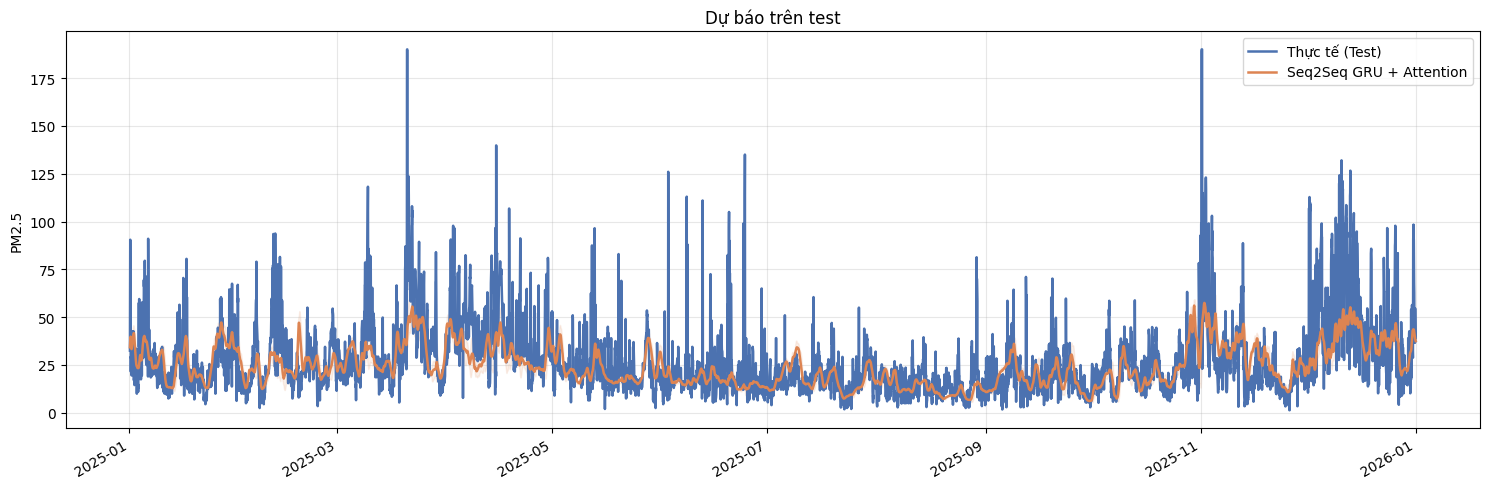

In [28]:
# ===== Walk-forward validate tren tap val, giu test hold-out =====

df_wf = df.copy().sort_index()

# Time cyclical features
df_wf["hour"] = df_wf.index.hour
df_wf["dayofweek"] = df_wf.index.dayofweek
df_wf["month"] = df_wf.index.month
df_wf["hour_sin"] = np.sin(2 * np.pi * df_wf["hour"] / 24)
df_wf["hour_cos"] = np.cos(2 * np.pi * df_wf["hour"] / 24)
df_wf["dow_sin"] = np.sin(2 * np.pi * df_wf["dayofweek"] / 7)
df_wf["dow_cos"] = np.cos(2 * np.pi * df_wf["dayofweek"] / 7)
df_wf["month_sin"] = np.sin(2 * np.pi * df_wf["month"] / 12)
df_wf["month_cos"] = np.cos(2 * np.pi * df_wf["month"] / 12)

# PM25 lag/rolling features
for lag in [1, 3, 6, 12, 24, 48, 72, 168]:
    df_wf[f"PM25_lag_{lag}"] = df_wf["PM25"].shift(lag)
shifted = df_wf["PM25"].shift(1)
for window in [24, 72, 168]:
    df_wf[f"PM25_roll_mean_{window}"] = shifted.rolling(window=window).mean()
    df_wf[f"PM25_roll_std_{window}"] = shifted.rolling(window=window).std()
    df_wf[f"PM25_roll_max_{window}"] = shifted.rolling(window=window).max()
    df_wf[f"PM25_roll_min_{window}"] = shifted.rolling(window=window).min()
df_wf["PM25_ewm_mean_24"] = shifted.ewm(span=24, adjust=False).mean()
df_wf["PM25_ewm_mean_72"] = shifted.ewm(span=72, adjust=False).mean()
df_wf["PM25_diff_1"] = shifted.diff(1)
df_wf["PM25_diff_24"] = shifted.diff(24)

df_wf = df_wf.dropna().copy()

train_wf = df_wf[:train_end].copy()
val_wf = df_wf[val_start:val_end].copy()
test_wf = df_wf[test_start:].copy()

missing_feature_cols = [c for c in feature_cols if c not in df_wf.columns]
if missing_feature_cols:
    raise ValueError(f"Thiếu các cột feature: {missing_feature_cols}")

val_X_pool = val_wf[feature_cols].copy()
val_y_pool = val_wf[["PM25"]].copy()

base_train_X = train_wf[feature_cols].copy()
base_train_y = train_wf[["PM25"]].copy()

MODEL_KWARGS = {
    "gru_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.15,
    "recurrent_dropout": 0.0,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}
MODEL_LABEL = "Seq2Seq GRU + Attention" if MODEL_KWARGS.get("use_attention", False) else "Seq2Seq GRU"


def make_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, min_delta=1e-4),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
    ]


def split_train_inner_val(train_X_df, train_y_df, inner_val_size):
    min_train_rows = LOOKBACK + HORIZON
    if len(train_X_df) <= inner_val_size + min_train_rows:
        raise ValueError(
            f"Không đủ dữ liệu để tách inner val. Cần > {inner_val_size + min_train_rows} rows, nhận {len(train_X_df)}"
        )
    train_core_X = train_X_df.iloc[:-inner_val_size].copy()
    train_core_y = train_y_df.iloc[:-inner_val_size].copy()
    inner_val_X = train_X_df.iloc[-inner_val_size:].copy()
    inner_val_y = train_y_df.iloc[-inner_val_size:].copy()
    return train_core_X, train_core_y, inner_val_X, inner_val_y


def fit_selector_model(train_core_X, train_core_y, inner_val_X, inner_val_y):
    X_train_seq, y_train_seq, X_inner_val_seq, y_inner_val_seq, x_scaler, y_scaler = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence cho train hoặc inner val. Kiểm tra lại kích thước dữ liệu và lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=HORIZON,
        loss_fn=loss_fn,
        **MODEL_KWARGS,
    )
    history = model.fit(
        X_train_seq,
        y_train_seq,
        validation_data=(X_inner_val_seq, y_inner_val_seq),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model(full_X_df, full_y_df, epochs):
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, y_full_seq = make_sequences(X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=HORIZON)

    if len(X_full_seq) == 0:
        raise ValueError("Không tạo được sequence full-history")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=HORIZON,
        loss_fn=loss_fn,
        **MODEL_KWARGS,
    )
    model.fit(
        X_full_seq,
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


fold_rows = []
compare_samples = []

for fold, start in enumerate(range(0, len(val_X_pool), STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = min(start + EVAL_SIZE, len(val_X_pool))
    fold_eval_X = val_X_pool.iloc[start:end].copy()
    fold_eval_y = val_y_pool.iloc[start:end].copy()

    if len(fold_eval_X) < HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_X_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_y_pool.iloc[:start]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model(
        train_core_X, train_core_y, inner_val_X, inner_val_y
    )

    X_eval_seq, y_eval_seq = prepare_eval_sequences(
        fold_history_X,
        fold_history_y,
        fold_eval_X,
        fold_eval_y,
        x_scaler,
        y_scaler,
        lookback=LOOKBACK,
        horizon=HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_eval_seq) == 0:
        continue

    y_pred_scaled = model.predict(X_eval_seq, verbose=0)
    y_true = inverse_target(y_eval_seq, y_scaler, mode=TARGET_TRANSFORM_MODE)
    y_pred = inverse_target(y_pred_scaled, y_scaler, mode=TARGET_TRANSFORM_MODE)

    eval_summary = summarize_multistep_predictions(
        fold_eval_X.index,
        y_true,
        y_pred,
        peak_quantile=PEAK_QUANTILE,
    )
    raw_metrics = eval_summary["raw_metrics"]
    step1_metrics = eval_summary["step1_metrics"]
    agg_metrics = eval_summary["agg_metrics"]

    compare_samples.append({
        "fold": fold,
        "step1_df": eval_summary["step1_df"],
        "agg_df": eval_summary["agg_df"],
        "horizon_metrics_df": eval_summary["horizon_metrics_df"],
    })

    fold_rows.append({
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "eval_rows": len(fold_eval_X),
        "val_mae_raw": raw_metrics["mae"],
        "val_rmse_raw": raw_metrics["rmse"],
        "val_mae_step1": step1_metrics["mae"],
        "val_rmse_step1": step1_metrics["rmse"],
        "val_mape_step1": step1_metrics["mape"],
        "val_peak_mae_step1": step1_metrics["peak_mae"],
        "val_peak_threshold_step1": step1_metrics["peak_threshold"],
        "val_mae_agg": agg_metrics["mae"],
        "val_rmse_agg": agg_metrics["rmse"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    })

walkforward_df = pd.DataFrame(fold_rows)
print("=== Walk-forward validation ===")
display(walkforward_df)

if not walkforward_df.empty:
    val_summary_df = pd.DataFrame([
        {
            "mean_val_mae_step1": walkforward_df["val_mae_step1"].mean(),
            "mean_val_rmse_step1": walkforward_df["val_rmse_step1"].mean(),
            "mean_val_mape_step1": walkforward_df["val_mape_step1"].mean(),
            "mean_val_mae_agg": walkforward_df["val_mae_agg"].mean(),
            "mean_val_rmse_agg": walkforward_df["val_rmse_agg"].mean(),
        }
    ])
    print("\n=== Validation summary ===")
    display(val_summary_df)



# ===== Khoa config tren validation, train tren train+val va danh gia 1 lan tren test =====
train_val_X = pd.concat([train_wf[feature_cols], val_wf[feature_cols]], axis=0)
train_val_y = pd.concat([train_wf[["PM25"]], val_wf[["PM25"]]], axis=0)
test_X = test_wf[feature_cols].copy()
test_y = test_wf[["PM25"]].copy()

train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
    train_val_X, train_val_y, INNER_VAL_SIZE
)
selector_model, selector_history, best_epoch_test, _, _, peak_threshold_test_train = fit_selector_model(
    train_core_X, train_core_y, inner_val_X, inner_val_y
)
test_model, x_scaler_test, y_scaler_test, peak_threshold_test_full = fit_full_history_model(
    train_val_X, train_val_y, best_epoch_test
)

X_test_seq, y_test_seq = prepare_eval_sequences(
    train_val_X,
    train_val_y,
    test_X,
    test_y,
    x_scaler_test,
    y_scaler_test,
    lookback=LOOKBACK,
    horizon=HORIZON,
    target_mode=TARGET_TRANSFORM_MODE,
)

if len(X_test_seq) == 0:
    raise ValueError("Không tạo được sequence cho tập test. Kiểm tra lại kích thước dữ liệu và lookback/horizon.")

y_test_pred_scaled = test_model.predict(X_test_seq, verbose=0)
y_test_true = inverse_target(y_test_seq, y_scaler_test, mode=TARGET_TRANSFORM_MODE)
y_test_pred = inverse_target(y_test_pred_scaled, y_scaler_test, mode=TARGET_TRANSFORM_MODE)

test_eval_summary = summarize_multistep_predictions(
    test_X.index,
    y_test_true,
    y_test_pred,
    peak_quantile=PEAK_QUANTILE,
)
test_timeline_long = test_eval_summary["long_df"]
test_timeline_agg = test_eval_summary["agg_df"]
test_step1_df = test_eval_summary["step1_df"]
test_horizon_metrics_df = test_eval_summary["horizon_metrics_df"]

test_raw_metrics = test_eval_summary["raw_metrics"]
test_step1_metrics = test_eval_summary["step1_metrics"]
test_agg_metrics = test_eval_summary["agg_metrics"]
test_metrics_df = pd.DataFrame([
    {
        "best_epoch": best_epoch_test,
        "test_mae_raw": test_raw_metrics["mae"],
        "test_rmse_raw": test_raw_metrics["rmse"],
        "test_mae_step1": test_step1_metrics["mae"],
        "test_rmse_step1": test_step1_metrics["rmse"],
        "test_mape_step1": test_step1_metrics["mape"],
        "test_peak_mae_step1": test_step1_metrics["peak_mae"],
        "test_mae_agg": test_agg_metrics["mae"],
        "test_rmse_agg": test_agg_metrics["rmse"],
        "train_peak_threshold_t": peak_threshold_test_train,
        "train_val_peak_threshold_t": peak_threshold_test_full,
    }
])
test_report_df = pd.DataFrame([
    {
        "model": MODEL_LABEL,
        "mae": test_step1_metrics["mae"],
        "rmse": test_step1_metrics["rmse"],
        "MAPE": test_step1_metrics["mape"],
        "best_epoch": best_epoch_test,
    }
])
print("\n=== Hold-out test metrics ===")
display(test_metrics_df)
print("\n=== Presentation table ===")
display(test_report_df)

plot_df = test_timeline_agg.copy()

plt.figure(figsize=(15, 5))
plt.plot(plot_df["timestamp"], plot_df["y_true"], label="Thực tế (Test)", linewidth=1.8, color="#4C72B0")
plt.plot(plot_df["timestamp"], plot_df["y_pred"], label=MODEL_LABEL, linewidth=1.8, color="#DD8452")
plt.fill_between(
    plot_df["timestamp"],
    plot_df["y_pred"] - plot_df["pred_std"],
    plot_df["y_pred"] + plot_df["pred_std"],
    color="#DD8452",
    alpha=0.12,
)
plt.title("Dự báo trên test")
plt.xlabel("")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()




In [ ]:
zoom_hours = 24 * 30
zoom_df = presentation_df.tail(zoom_hours).copy()
plt.figure(figsize=(16, 5))
plt.plot(zoom_df["timestamp"], zoom_df["actual"], label="Thực tế (Test)", linewidth=1.9, color="tab:blue")
plt.plot(zoom_df["timestamp"], zoom_df["seq2seq_gru"], label="Seq2Seq GRU", linewidth=1.6, alpha=0.95, color="tab:green")
plt.plot(zoom_df["timestamp"], zoom_df["seq2seq_gru_attention"], label="Seq2Seq GRU + Attention", linewidth=1.6, alpha=0.95, color="tab:red")
plt.title("Zoom 14 ngày cuối trên test")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# ===== Feature-set comparison (fixed model) =====

FEATURE_COMPARE_MODEL_LABEL = "Seq2Seq GRU + Attention"
FEATURE_COMPARE_MODEL_KWARGS = {**MODEL_KWARGS, "use_attention": True}
FEATURE_COMPARE_MAX_EPOCHS = min(EPOCHS, 30)
FEATURE_COMPARE_BATCH_SIZE = BATCH_SIZE


# Chay cung mot kien truc model tren nhieu bo feature de xem bo nao giam loi tot hon.
def run_feature_set_variant(feature_set_name, model_label, model_kwargs):
    local_feature_cols = candidate_feature_sets[feature_set_name]

    train_val_X_local = pd.concat([train_wf[local_feature_cols], val_wf[local_feature_cols]], axis=0)
    train_val_y_local = pd.concat([train_wf[["PM25"]], val_wf[["PM25"]]], axis=0)
    test_X_local = test_wf[local_feature_cols].copy()
    test_y_local = test_wf[["PM25"]].copy()

    train_core_X_local, train_core_y_local, inner_val_X_local, inner_val_y_local = split_train_inner_val(
        train_val_X_local, train_val_y_local, INNER_VAL_SIZE
    )

    X_train_seq_local, y_train_seq_local, X_inner_val_seq_local, y_inner_val_seq_local, _, _ = prepare_train_eval_sequences(
        train_core_X_local,
        train_core_y_local,
        inner_val_X_local,
        inner_val_y_local,
        lookback=LOOKBACK,
        horizon=HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    peak_threshold_train = float(np.quantile(y_train_seq_local.reshape(-1), PEAK_QUANTILE))
    loss_fn_local = make_weighted_huber_loss(
        peak_threshold=peak_threshold_train,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=HORIZON,
    )

    selector_model_local = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq_local.shape[2],
        horizon=HORIZON,
        loss_fn=loss_fn_local,
        **model_kwargs,
    )
    selector_history_local = selector_model_local.fit(
        X_train_seq_local,
        y_train_seq_local,
        validation_data=(X_inner_val_seq_local, y_inner_val_seq_local),
        epochs=FEATURE_COMPARE_MAX_EPOCHS,
        batch_size=FEATURE_COMPARE_BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch_local = int(np.argmin(selector_history_local.history["val_loss"])) + 1

    x_scaler_local = StandardScaler()
    X_full_scaled_local = x_scaler_local.fit_transform(train_val_X_local.values)
    y_full_scaled_local, y_scaler_local = transform_target(
        train_val_y_local.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq_local, y_full_seq_local = make_sequences(
        X_full_scaled_local, y_full_scaled_local, lookback=LOOKBACK, horizon=HORIZON
    )
    peak_threshold_full = float(np.quantile(y_full_seq_local.reshape(-1), PEAK_QUANTILE))
    full_loss_fn_local = make_weighted_huber_loss(
        peak_threshold=peak_threshold_full,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=HORIZON,
    )

    final_model_local = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq_local.shape[2],
        horizon=HORIZON,
        loss_fn=full_loss_fn_local,
        **model_kwargs,
    )
    final_model_local.fit(
        X_full_seq_local,
        y_full_seq_local,
        epochs=best_epoch_local,
        batch_size=FEATURE_COMPARE_BATCH_SIZE,
        verbose=0,
    )

    X_test_seq_local, y_test_seq_local = prepare_eval_sequences(
        train_val_X_local,
        train_val_y_local,
        test_X_local,
        test_y_local,
        x_scaler_local,
        y_scaler_local,
        lookback=LOOKBACK,
        horizon=HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    y_test_pred_scaled_local = final_model_local.predict(X_test_seq_local, verbose=0)
    y_test_true_local = inverse_target(y_test_seq_local, y_scaler_local, mode=TARGET_TRANSFORM_MODE)
    y_test_pred_local = inverse_target(y_test_pred_scaled_local, y_scaler_local, mode=TARGET_TRANSFORM_MODE)

    summary_local = summarize_multistep_predictions(
        test_X_local.index,
        y_test_true_local,
        y_test_pred_local,
        peak_quantile=PEAK_QUANTILE,
    )

    return {
        "feature_set": feature_set_name,
        "label": model_label,
        "best_epoch": best_epoch_local,
        "n_features": len(local_feature_cols),
        "metrics": {
            "feature_set": feature_set_name,
            "n_features": len(local_feature_cols),
            "best_epoch": best_epoch_local,
            "test_mae_step1": summary_local["step1_metrics"]["mae"],
            "test_rmse_step1": summary_local["step1_metrics"]["rmse"],
            "test_mape_step1": summary_local["step1_metrics"]["mape"],
            "test_peak_mae_step1": summary_local["step1_metrics"]["peak_mae"],
            "test_mae_agg": summary_local["agg_metrics"]["mae"],
            "test_rmse_agg": summary_local["agg_metrics"]["rmse"],
        },
        "step1_df": summary_local["step1_df"].copy(),
    }


feature_compare_results = []
for feature_set_name in FEATURE_SET_COMPARE:
    print(f"Dang danh gia feature set: {feature_set_name}")
    feature_compare_results.append(
        run_feature_set_variant(
            feature_set_name=feature_set_name,
            model_label=FEATURE_COMPARE_MODEL_LABEL,
            model_kwargs=FEATURE_COMPARE_MODEL_KWARGS,
        )
    )

feature_compare_df = pd.DataFrame([res["metrics"] for res in feature_compare_results])
feature_compare_df = feature_compare_df.sort_values(["test_mae_step1", "test_mae_agg"]).reset_index(drop=True)
print("=== So sanh feature set tren test ===")
display(feature_compare_df)

best_feature_set = feature_compare_df.loc[0, "feature_set"]
print("Feature set dang uu tien de dung tiep:", best_feature_set)
print("Neu ket qua dung huong, giu SELECTED_FEATURE_SET =", best_feature_set)


Dang danh gia feature set: gra_topk
Dang danh gia feature set: base_weather_pollution
Dang danh gia feature set: manual_v1
=== So sanh feature set tren test ===


,feature_set,n_features,best_epoch,test_mae_step1,test_rmse_step1,test_mape_step1,test_peak_mae_step1,test_mae_agg,test_rmse_agg
0,gra_topk,12,2,7.550681,11.999563,34.055795,23.608471,9.866624,14.848554
1,base_weather_pollution,33,1,8.022094,13.349139,33.175044,29.803900,9.392114,14.863726
2,manual_v1,37,5,8.489677,13.615262,34.433323,25.548874,9.961036,16.262712


Feature set dang uu tien de dung tiep: gra_topk
Neu ket qua dung huong, giu SELECTED_FEATURE_SET = gra_topk


Đang train để so sánh cho: Seq2Seq GRU
Tái sử dụng kết quả đã có cho: Seq2Seq GRU + Attention
=== Bảng so sánh ===


,model,mae,rmse,MAPE
0,Seq2Seq GRU,7.374182,12.126029,30.553017
1,Seq2Seq GRU + Attention,8.011371,12.701660,34.174811


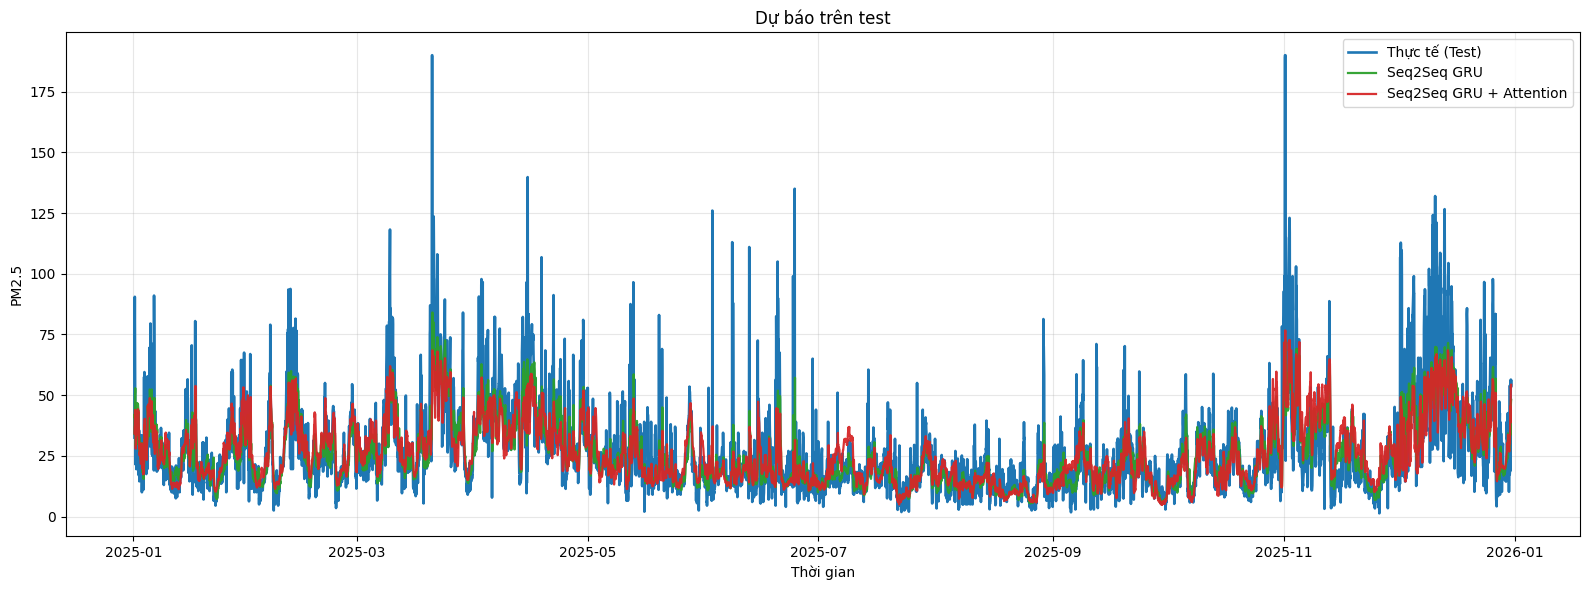

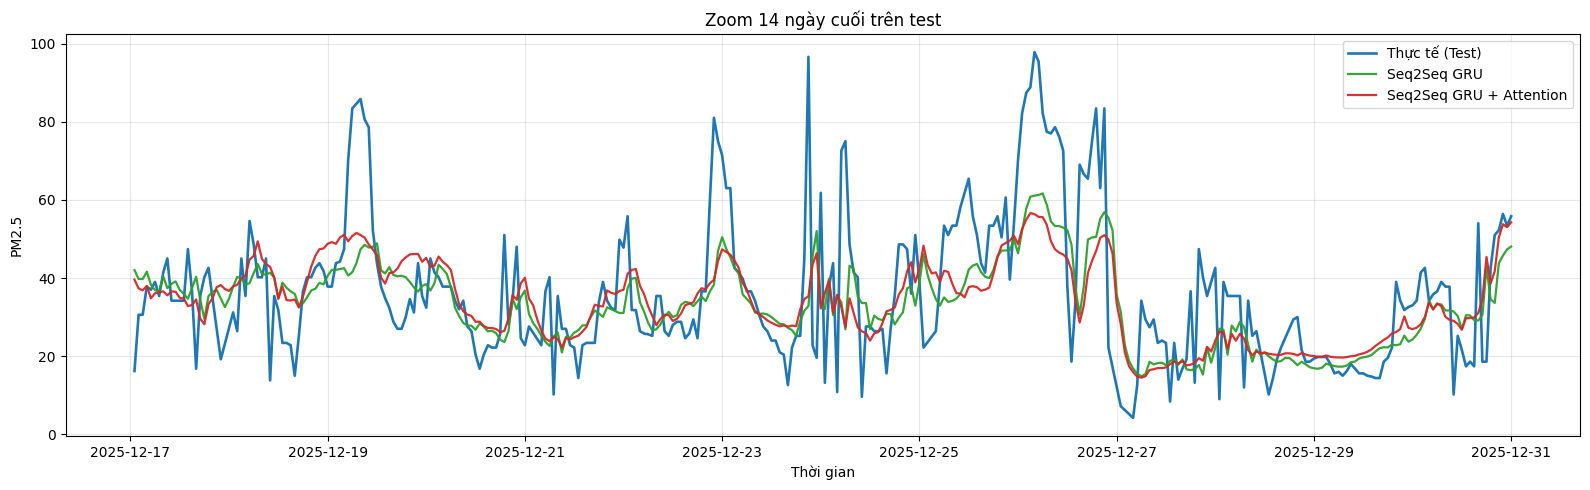

In [31]:
# ===== Presentation dashboard: Seq2Seq GRU vs Seq2Seq GRU + Attention =====

COMPARE_MODEL_CONFIGS = [
    ("Seq2Seq GRU", {**MODEL_KWARGS, "use_attention": False}),
    ("Seq2Seq GRU + Attention", {**MODEL_KWARGS, "use_attention": True}),
]
COMPARE_REUSE_CURRENT_RESULTS = True
COMPARE_MAX_EPOCHS = min(EPOCHS, 30)
COMPARE_BATCH_SIZE = BATCH_SIZE


# Dong goi ket qua da co san tu cell test chinh de tranh train lai mot mo hinh.
def build_cached_result(model_label, model_kwargs):
    return {
        "label": model_label,
        "model_kwargs": model_kwargs,
        "best_epoch": best_epoch_test,
        "metrics": {
            "model": model_label,
            "mae": test_step1_metrics["mae"],
            "rmse": test_step1_metrics["rmse"],
            "MAPE": test_step1_metrics["mape"],
        },
        "step1_df": test_step1_df.copy(),
    }


# Huan luyen va danh gia mot bien the model cu the, chi lay cac thanh phan can cho dashboard trinh bay.
def run_test_variant(model_label, model_kwargs):
    train_val_X_local = pd.concat([train_wf[feature_cols], val_wf[feature_cols]], axis=0)
    train_val_y_local = pd.concat([train_wf[["PM25"]], val_wf[["PM25"]]], axis=0)
    test_X_local = test_wf[feature_cols].copy()
    test_y_local = test_wf[["PM25"]].copy()

    train_core_X_local, train_core_y_local, inner_val_X_local, inner_val_y_local = split_train_inner_val(
        train_val_X_local,
        train_val_y_local,
        INNER_VAL_SIZE
    )

    X_train_seq_local, y_train_seq_local, X_inner_val_seq_local, y_inner_val_seq_local, _, _ = prepare_train_eval_sequences(
        train_core_X_local,
        train_core_y_local,
        inner_val_X_local,
        inner_val_y_local,
        lookback=LOOKBACK,
        horizon=HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    peak_threshold_train = float(np.quantile(y_train_seq_local.reshape(-1), PEAK_QUANTILE))
    loss_fn_local = make_weighted_huber_loss(
        peak_threshold=peak_threshold_train,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=HORIZON,
    )

    selector_model_local = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq_local.shape[2],
        horizon=HORIZON,
        loss_fn=loss_fn_local,
        **model_kwargs,
    )
    selector_history_local = selector_model_local.fit(
        X_train_seq_local,
        y_train_seq_local,
        validation_data=(X_inner_val_seq_local, y_inner_val_seq_local),
        epochs=COMPARE_MAX_EPOCHS,
        batch_size=COMPARE_BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch_local = int(np.argmin(selector_history_local.history["val_loss"])) + 1

    x_scaler_local = StandardScaler()
    X_full_scaled_local = x_scaler_local.fit_transform(train_val_X_local.values)
    y_full_scaled_local, y_scaler_local = transform_target(
        train_val_y_local.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq_local, y_full_seq_local = make_sequences(
        X_full_scaled_local, y_full_scaled_local, lookback=LOOKBACK, horizon=HORIZON
    )
    peak_threshold_full = float(np.quantile(y_full_seq_local.reshape(-1), PEAK_QUANTILE))
    full_loss_fn_local = make_weighted_huber_loss(
        peak_threshold=peak_threshold_full,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=HORIZON,
    )

    final_model_local = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq_local.shape[2],
        horizon=HORIZON,
        loss_fn=full_loss_fn_local,
        **model_kwargs,
    )
    final_model_local.fit(
        X_full_seq_local,
        y_full_seq_local,
        epochs=best_epoch_local,
        batch_size=COMPARE_BATCH_SIZE,
        verbose=0,
    )

    X_test_seq_local, y_test_seq_local = prepare_eval_sequences(
        train_val_X_local,
        train_val_y_local,
        test_X_local,
        test_y_local,
        x_scaler_local,
        y_scaler_local,
        lookback=LOOKBACK,
        horizon=HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    y_test_pred_scaled_local = final_model_local.predict(X_test_seq_local, verbose=0)
    y_test_true_local = inverse_target(y_test_seq_local, y_scaler_local, mode=TARGET_TRANSFORM_MODE)
    y_test_pred_local = inverse_target(y_test_pred_scaled_local, y_scaler_local, mode=TARGET_TRANSFORM_MODE)

    summary_local = summarize_multistep_predictions(
        test_X_local.index,
        y_test_true_local,
        y_test_pred_local,
        peak_quantile=PEAK_QUANTILE,
    )

    return {
        "label": model_label,
        "model_kwargs": model_kwargs,
        "best_epoch": best_epoch_local,
        "metrics": {
            "model": model_label,
            "mae": summary_local["step1_metrics"]["mae"],
            "rmse": summary_local["step1_metrics"]["rmse"],
            "MAPE": summary_local["step1_metrics"]["mape"],
        },
        "step1_df": summary_local["step1_df"].copy(),
    }


presentation_results = []
for model_label, model_kwargs in COMPARE_MODEL_CONFIGS:
    can_reuse_current = (
        COMPARE_REUSE_CURRENT_RESULTS
        and "test_step1_df" in globals()
        and model_label == MODEL_LABEL
    )

    if can_reuse_current:
        print(f"Tái sử dụng kết quả đã có cho: {model_label}")
        presentation_results.append(build_cached_result(model_label, model_kwargs))
    else:
        print(f"Đang train để so sánh cho: {model_label}")
        presentation_results.append(run_test_variant(model_label, model_kwargs))

presentation_metrics_df = pd.DataFrame([res["metrics"] for res in presentation_results])
presentation_metrics_df = presentation_metrics_df.sort_values("mae").reset_index(drop=True)
print("=== Bảng so sánh ===")
display(presentation_metrics_df)

seq2seq_res = next(res for res in presentation_results if res["label"] == "Seq2Seq GRU")
attn_res = next(res for res in presentation_results if res["label"] == "Seq2Seq GRU + Attention")

presentation_df = seq2seq_res["step1_df"][["timestamp", "y_true"]].copy()
presentation_df = presentation_df.rename(columns={"y_true": "actual"})
presentation_df["seq2seq_gru"] = seq2seq_res["step1_df"]["y_pred"].to_numpy()
presentation_df["seq2seq_gru_attention"] = attn_res["step1_df"]["y_pred"].to_numpy()

plt.figure(figsize=(16, 6))
plt.plot(presentation_df["timestamp"], presentation_df["actual"], label="Thực tế (Test)", linewidth=1.9, color="tab:blue")
plt.plot(presentation_df["timestamp"], presentation_df["seq2seq_gru"], label="Seq2Seq GRU", linewidth=1.6, alpha=0.95, color="tab:green")
plt.plot(presentation_df["timestamp"], presentation_df["seq2seq_gru_attention"], label="Seq2Seq GRU + Attention", linewidth=1.6, alpha=0.95, color="tab:red")
plt.title("Dự báo trên test")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

zoom_hours = 24 * 14
zoom_df = presentation_df.tail(zoom_hours).copy()
plt.figure(figsize=(16, 5))
plt.plot(zoom_df["timestamp"], zoom_df["actual"], label="Thực tế (Test)", linewidth=1.9, color="tab:blue")
plt.plot(zoom_df["timestamp"], zoom_df["seq2seq_gru"], label="Seq2Seq GRU", linewidth=1.6, alpha=0.95, color="tab:green")
plt.plot(zoom_df["timestamp"], zoom_df["seq2seq_gru_attention"], label="Seq2Seq GRU + Attention", linewidth=1.6, alpha=0.95, color="tab:red")
plt.title("Zoom 14 ngày cuối trên test")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()